In [1]:
pip install pandas transformers torch

--- Инициализация системы на GPU ---


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-base-cased-nli-twoway
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Этап 1: Очистка и нормализация данных...
Этап 2: Анализ 458 отзывов...


100%|██████████| 58/58 [00:27<00:00,  2.08it/s]


Этап 3: Создание визуализации...
Визуализация сохранена в 'reputation_dashboard.png'


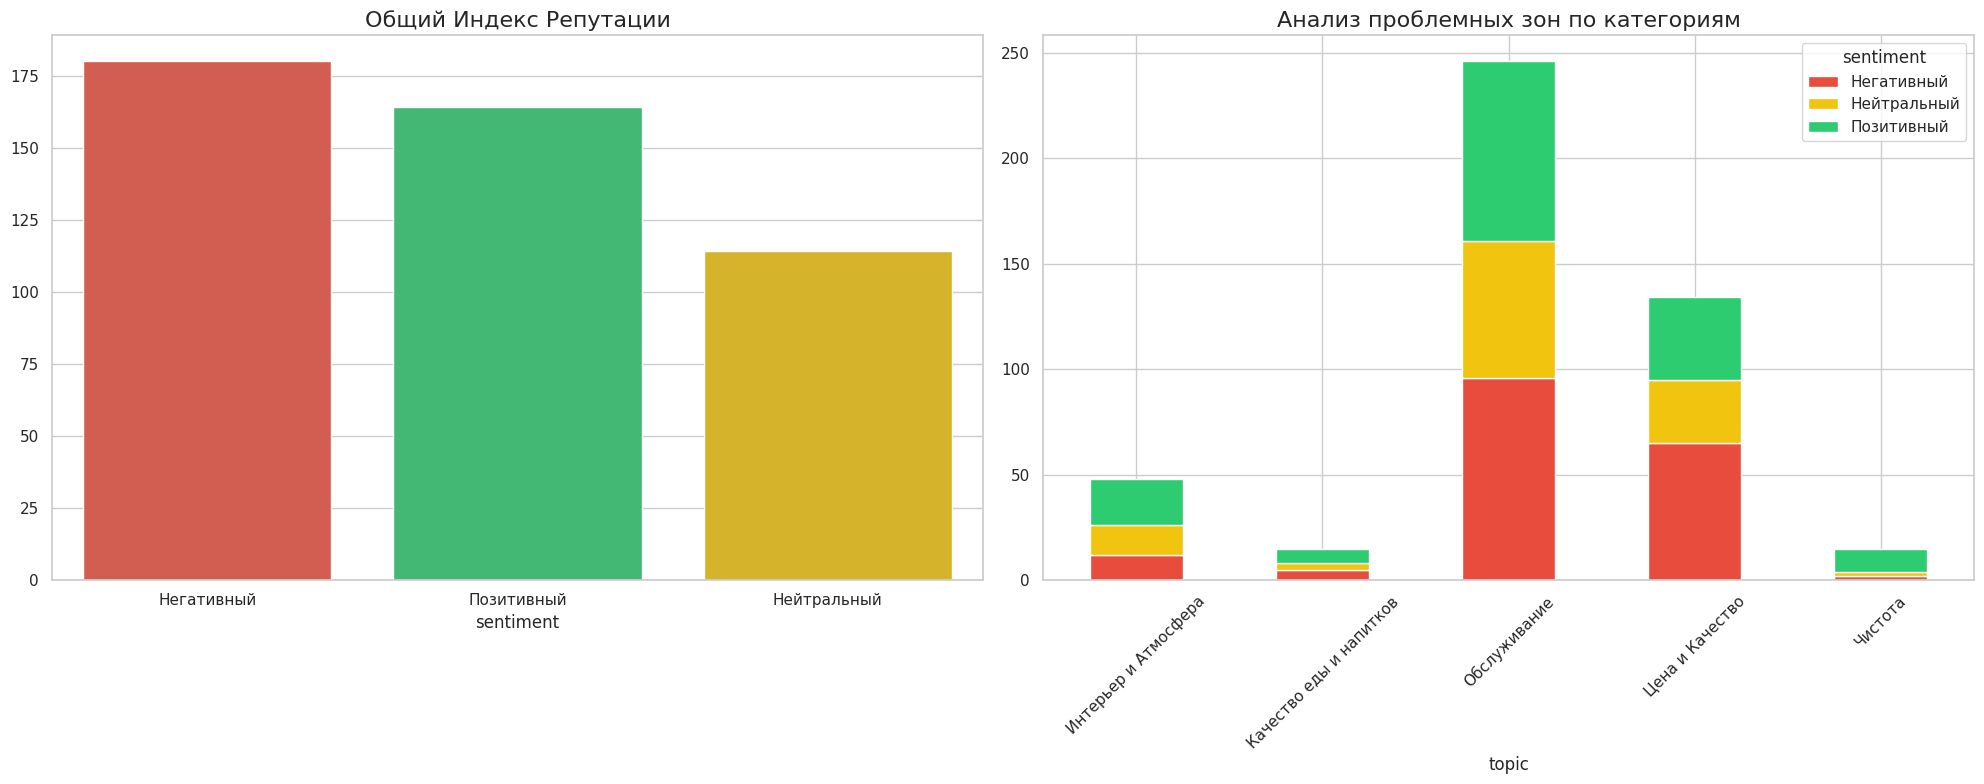


Готово! Все этапы проекта Reputation Meter выполнены успешно.


In [26]:
import pandas as pd
import torch
import csv
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from tqdm import tqdm

warnings.filterwarnings('ignore')

class ReputationMeterMVP:
    def __init__(self):
        self.device = 0 if torch.cuda.is_available() else -1
        self.categories = [
            "Обслуживание",
            "Качество еды и напитков",
            "Чистота",
            "Интерьер и Атмосфера",
            "Цена и Качество"
        ]
        print(f"--- Инициализация системы на { 'GPU' if self.device == 0 else 'CPU' } ---")

        self.sentiment_pipe = pipeline(
            "sentiment-analysis",
            model="blanchefort/rubert-base-cased-sentiment",
            device=self.device
        )
        self.topic_pipe = pipeline(
            "zero-shot-classification",
            model="cointegrated/rubert-base-cased-nli-twoway",
            device=self.device
        )

    def sanitize_data(self, input_path, output_path):
        """Очистка CSV от переносов строк внутри текстов отзывов."""
        print("Этап 1: Очистка и нормализация данных...")
        with open(input_path, 'r', encoding='utf-8') as f_in, \
             open(output_path, 'w', encoding='utf-8', newline='') as f_out:
            reader = csv.reader(f_in)
            writer = csv.writer(f_out)
            header = next(reader, None)
            if header:
                writer.writerow(header)
                for row in reader:
                    clean_row = [field.replace('\r', ' ').replace('\n', ' ') for field in row]
                    writer.writerow(clean_row)

    def run_nlp_analysis(self, temp_csv, output_csv, batch_size=8):
        """Пакетный NLP анализ текстов."""
        df = pd.read_csv(temp_csv).dropna(subset=['review_text'])
        texts = df['review_text'].astype(str).tolist()

        results = []
        print(f"Этап 2: Анализ {len(texts)} отзывов...")

        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i + batch_size]
            try:
                sents = self.sentiment_pipe(batch, truncation=True, max_length=512)
                topics = self.topic_pipe(batch, self.categories, truncation=True, max_length=512)

                for j in range(len(batch)):
                    results.append({
                        'sentiment': self._map_sentiment(sents[j]['label']),
                        'topic': topics[j]['labels'][0],
                        'confidence': round(topics[j]['scores'][0], 3)
                    })
            except Exception:
                for _ in range(len(batch)):
                    results.append({'sentiment': 'Ошибка', 'topic': 'Ошибка', 'confidence': 0})

        final_df = pd.concat([df.reset_index(drop=True), pd.DataFrame(results)], axis=1)
        final_df.to_csv(output_csv, index=False, encoding='utf-8-sig')
        return final_df

    def _map_sentiment(self, label):
        mapping = {'POSITIVE': 'Позитивный', 'NEGATIVE': 'Негативный', 'NEUTRAL': 'Нейтральный'}
        return mapping.get(label, label)

    def create_dashboard(self, df):
        """Генерация графиков для отчета."""
        print("Этап 3: Создание визуализации...")
        sns.set_theme(style="whitegrid")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

        colors = {'Позитивный': '#2ecc71', 'Нейтральный': '#f1c40f', 'Негативный': '#e74c3c'}

        sent_data = df['sentiment'].value_counts()
        sns.barplot(x=sent_data.index, y=sent_data.values,
                    palette=[colors.get(x, '#3498db') for x in sent_data.index], ax=ax1)
        ax1.set_title('Общий Индекс Репутации', fontsize=16)

        ct = pd.crosstab(df['topic'], df['sentiment'])
        ct.plot(kind='bar', stacked=True,
                color=[colors.get(col, '#3498db') for col in ct.columns], ax=ax2)
        ax2.set_title('Анализ проблемных зон по категориям', fontsize=16)
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.savefig('reputation_dashboard.png')
        print("Визуализация сохранена в 'reputation_dashboard.png'")
        plt.show()

if __name__ == "__main__":
    app = ReputationMeterMVP()
    app.sanitize_data('example.csv', 'fixed_temp.csv')

    final_results = app.run_nlp_analysis('fixed_temp.csv', 'final_reputation_report.csv')
    app.create_dashboard(final_results)

    print("\nГотово! Все этапы проекта Reputation Meter выполнены успешно.")

In [27]:
result = pd.read_csv('final_reputation_report.csv')

In [28]:
result

,author_None,author_image,author_name,author_url,datetime_None,datetime_datePublished,dislike,is_a_response,like,response_datetime,response_text,review_rating_bestRating,review_rating_ratingValue,review_rating_worstRating,review_text,selenium_id,sentiment,topic,confidence
0,"[None, 'Наталья Юнт']",['https://avatars.mds.yandex.net/get-yapic/477...,"[None, 'Наталья Юнт']",NaN,"[None, 'November 12, 2025']","['2025-11-12T15:27:13.892Z', '']",Наталья Юнт Level 8 Local Expert Subscribe Nov...,False,Наталья Юнт Level 8 Local Expert Subscribe Nov...,Наталья Юнт Level 8 Local Expert Subscribe Nov...,Наталья Юнт Level 8 Local Expert Subscribe Nov...,"['5', '']","['5.0', '']","['1', '']",Наталья Юнт Level 8 Local Expert Subscribe Nov...,faaff941-c8a9-40da-9f09-ff7bfb79fb46,Позитивный,Обслуживание,0.350
1,"[None, 'Лариса']",['https://avatars.mds.yandex.net/get-yapic/371...,"[None, 'Лариса']",NaN,"[None, 'April 7']","['2026-04-07T16:28:59.571Z', '']",Лариса Level 3 Local Expert Subscribe April 7 ...,False,Лариса Level 3 Local Expert Subscribe April 7 ...,Лариса Level 3 Local Expert Subscribe April 7 ...,Лариса Level 3 Local Expert Subscribe April 7 ...,"['5', '']","['5.0', '']","['1', '']",Лариса Level 3 Local Expert Subscribe April 7 ...,27cb9f75-d2be-44e1-85b9-1d550f3cba47,Нейтральный,Интерьер и Атмосфера,0.306
2,"[None, 'Ирина Юрьевна Торсунова']",['https://avatars.mds.yandex.net/get-yapic/293...,"[None, 'Ирина Юрьевна Торсунова']",NaN,"[None, 'March 10']","['2026-03-10T18:24:56.286Z', '']",Ирина Юрьевна Торсунова Level 2 Local Expert S...,False,Ирина Юрьевна Торсунова Level 2 Local Expert S...,Ирина Юрьевна Торсунова Level 2 Local Expert S...,Ирина Юрьевна Торсунова Level 2 Local Expert S...,"['5', '']","['5.0', '']","['1', '']",Ирина Юрьевна Торсунова Level 2 Local Expert S...,243c4700-1fae-4661-9d4a-876947122a6b,Позитивный,Цена и Качество,0.496
3,"[None, 'Вячеслав Барков']",['https://avatars.mds.yandex.net/get-yapic/253...,"[None, 'Вячеслав Барков']",NaN,"[None, 'December 27, 2025']","['2025-12-27T14:16:40.413Z', '']",Вячеслав Барков Level 9 Local Expert Subscribe...,False,Вячеслав Барков Level 9 Local Expert Subscribe...,Вячеслав Барков Level 9 Local Expert Subscribe...,Вячеслав Барков Level 9 Local Expert Subscribe...,"['5', '']","['5.0', '']","['1', '']",Вячеслав Барков Level 9 Local Expert Subscribe...,b8977c66-f594-4982-bc8a-55f3d652b19a,Нейтральный,Обслуживание,0.584
4,"[None, 'Ольга Корякина']",['https://avatars.mds.yandex.net/get-yapic/310...,"[None, 'Ольга Корякина']",NaN,"[None, 'March 5']","['2026-03-05T07:49:20.789Z', '']",Ольга Корякина Level 18 Local Expert Subscribe...,False,Ольга Корякина Level 18 Local Expert Subscribe...,Ольга Корякина Level 18 Local Expert Subscribe...,Ольга Корякина Level 18 Local Expert Subscribe...,"['5', '']","['3.0', '']","['1', '']",Ольга Корякина Level 18 Local Expert Subscribe...,fab060fa-c7e9-4e66-88a6-e1bf077ef355,Негативный,Обслуживание,0.293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,"[None, 'Олеся Евгеньевна Задран']",['https://avatars.mds.yandex.net/get-yapic/272...,"[None, 'Олеся Евгеньевна Задран']",NaN,"[None, 'July 18, 2022']","['2022-07-18T07:05:41.013Z', '']",Олеся Евгеньевна Задран Level 5 Local Expert S...,False,Олеся Евгеньевна Задран Level 5 Local Expert S...,Олеся Евгеньевна Задран Level 5 Local Expert S...,Олеся Евгеньевна Задран Level 5 Local Expert S...,"['5', '']","['5.0', '']","['1', '']",Олеся Евгеньевна Задран Level 5 Local Expert S...,6eaaa7ba-1a6f-419f-9c40-70012cd68c3d,Негативный,Цена и Качество,0.398
454,NaN,['https://avatars.mds.yandex.net/get-yapic/500...,"[None, 'Альберт Котельников']",NaN,"[None, 'May 27, 2023']","['2023-05-27T15:06:26.537Z', '']",Альберт Котельников Level 12 Local Expert May ...,False,Альберт Котельников Level 12 Local Expert May ...,Альберт Котельников Level 12 Local Expert May ...,Альберт Котельников Level 12 Local Expert May ...,"['5', '']","['1.0', '']","['1', '']",Альберт Котельников Level 12 Loc